# KNN Classification Model - HDB Town Prediction

A step-by-step guide for building and evaluating K-Nearest Neighbors classification models.

**Objective:** Classify HDB towns based on property and location features.

---

## Step 1: Identify the Target Variable (y)

Define the categorical variable you want to predict (the dependent variable).

In [43]:
# ========== MODIFY THIS ==========
TARGET_COLUMN = 'town'  # Categorical target: town classification

# Note: TARGET_MAPPING will be created dynamically after loading data
# since there are many towns in Singapore
TARGET_MAPPING = None  # Will be populated in Step 2
# =================================

---

## Step 2: Import Packages and Load Dataset

In [44]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Optional boosting libraries
try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

# Configure plot settings
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 14
plt.style.use("fivethirtyeight")

# Suppress warnings
warnings.filterwarnings('ignore')

print("Packages imported successfully!")

Packages imported successfully!


In [45]:
# ========== MODIFY THIS ==========
# Load your dataset
DATA_PATH = 'data.csv'
# =================================

df = pd.read_csv(DATA_PATH)

# Create TARGET_MAPPING dynamically from unique town values
TARGET_MAPPING = {town: idx for idx, town in enumerate(sorted(df[TARGET_COLUMN].unique()))}
print(f"Towns found: {len(TARGET_MAPPING)}")
print(f"Town mapping: {TARGET_MAPPING}")

# Preview the data
print(f"\nDataset loaded with shape: {df.shape}")
df.head()

Towns found: 26
Town mapping: {'ANG MO KIO': 0, 'BEDOK': 1, 'BISHAN': 2, 'BUKIT BATOK': 3, 'BUKIT MERAH': 4, 'BUKIT PANJANG': 5, 'BUKIT TIMAH': 6, 'CENTRAL AREA': 7, 'CHOA CHU KANG': 8, 'CLEMENTI': 9, 'GEYLANG': 10, 'HOUGANG': 11, 'JURONG EAST': 12, 'JURONG WEST': 13, 'KALLANG/WHAMPOA': 14, 'MARINE PARADE': 15, 'PASIR RIS': 16, 'PUNGGOL': 17, 'QUEENSTOWN': 18, 'SEMBAWANG': 19, 'SENGKANG': 20, 'SERANGOON': 21, 'TAMPINES': 22, 'TOA PAYOH': 23, 'WOODLANDS': 24, 'YISHUN': 25}

Dataset loaded with shape: (65954, 76)


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978.0,515000.0,...,61.0,0.0,1.369092,103.839041,474.789674,Ang Mo Kio Secondary School,224.0,0.0,1.367359,103.842600
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978.0,368000.0,...,61.0,0.0,1.369092,103.839041,522.935557,Mayflower Secondary School,219.0,0.0,1.368337,103.835439
2,2012-03,ANG MO KIO,4 ROOM,105,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978.0,430000.0,...,61.0,0.0,1.369092,103.839041,398.421190,CHIJ Saint Nicholas Girls' School,256.0,1.0,1.373730,103.834309
3,2012-03,ANG MO KIO,4 ROOM,108,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978.0,427000.0,...,61.0,0.0,1.369092,103.839041,424.046635,Mayflower Secondary School,219.0,0.0,1.368337,103.835439
4,2012-03,ANG MO KIO,3 ROOM,110,ANG MO KIO AVE 4,01 TO 05,67.0,New Generation,1978.0,323000.0,...,61.0,0.0,1.369092,103.839041,322.732547,Mayflower Secondary School,219.0,0.0,1.368337,103.835439


---

## Step 3: Explore the Dataset Structure

Check the number of features, data types, and basic statistics.

In [46]:
# Check dimensions (rows, columns)
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print("\n" + "="*50)

# Check for missing values
print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0])

# View column names and data types
print("\nColumn Info:")
df.info()

Dataset shape: (65954, 76)
Number of features: 76


Missing values per column:
block                1
street_name          1
storey_range         1
floor_area_sqm       1
flat_model           1
                    ..
sec_sch_name         1
cutoff_point         1
affiliation          1
sec_sch_latitude     1
sec_sch_longitude    1
Length: 73, dtype: int64

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65954 entries, 0 to 65953
Data columns (total 76 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Tranc_YearMonth            65954 non-null  object 
 1   town                       65954 non-null  object 
 2   flat_type                  65954 non-null  object 
 3   block                      65953 non-null  object 
 4   street_name                65953 non-null  object 
 5   storey_range               65953 non-null  object 
 6   floor_area_sqm             65953 non-null  float64
 7   flat_model 

In [47]:
# View basic statistics
df.describe()

,floor_area_sqm,lease_commence_date,resale_price,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,floor_area_sqft,...,pri_sch_nearest_distance,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
count,65953.000000,65953.000000,6.595300e+04,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000,...,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000
mean,96.473275,1989.937577,4.525337e+05,2013.812745,6.394705,7.853638,6.770382,8.936894,7.853638,1038.438331,...,394.153067,60.311995,0.117159,1.364636,103.837585,506.061741,209.774188,0.031644,1.364506,103.837780
std,24.650257,10.348219,1.277278e+05,1.389703,3.187496,5.089826,5.099895,5.094741,5.089826,265.335370,...,233.025335,16.407967,0.321612,0.042827,0.073784,311.345706,19.907082,0.175051,0.042803,0.073763
min,31.000000,1966.000000,1.950000e+05,2012.000000,1.000000,2.000000,1.000000,3.000000,2.000000,333.684000,...,45.668324,5.000000,0.000000,1.274962,103.687724,38.913475,188.000000,0.000000,1.276029,103.687207
25%,74.000000,1983.000000,3.600000e+05,2013.000000,4.000000,5.000000,4.000000,6.000000,5.000000,796.536000,...,227.368700,51.000000,0.000000,1.336404,103.773698,288.966876,188.000000,0.000000,1.335256,103.774499
50%,95.000000,1988.000000,4.300000e+05,2014.000000,6.000000,8.000000,7.000000,9.000000,8.000000,1022.580000,...,347.979906,61.000000,0.000000,1.359059,103.841238,444.522859,208.000000,0.000000,1.359273,103.842547
75%,111.000000,1999.000000,5.170000e+05,2015.000000,9.000000,11.000000,10.000000,12.000000,11.000000,1194.804000,...,501.503554,70.000000,0.000000,1.390662,103.897865,635.719640,224.000000,0.000000,1.390040,103.898927
max,280.000000,2013.000000,1.088888e+06,2016.000000,12.000000,50.000000,49.000000,51.000000,50.000000,3013.920000,...,3305.841039,136.000000,1.000000,1.456667,103.962919,3638.977233,260.000000,1.000000,1.453280,103.961105


In [48]:
# ========== DEFINE COLUMNS TO USE ==========
# Only drop missing values for columns we'll actually use
# This prevents losing 80%+ of data due to columns we don't need

COLUMNS_TO_USE = [
    # Core features (no missing values)
    'mrt_nearest_distance',
    'Hawker_Nearest_Distance',
    'hdb_age',
    'max_floor_lvl',
    'floor_area_sqm',
    'mid_storey',
    # Target
    'town',
]
# Note: Removed Mall_Nearest_Distance as it has ~2% missing values
# Note: Avoided Hawker_Within_500m (65% missing), Mall_Within_500m (62% missing)
# ===========================================

# Drop rows with missing values ONLY in columns we'll use
rows_before = len(df)
df = df.dropna(subset=COLUMNS_TO_USE)
rows_after = len(df)
rows_dropped = rows_before - rows_after
pct_dropped = (rows_dropped / rows_before) * 100

print(f"Rows before cleanup: {rows_before}")
print(f"Rows after cleanup: {rows_after}")
print(f"Rows dropped: {rows_dropped} ({pct_dropped:.2f}%)")

Rows before cleanup: 65954
Rows after cleanup: 65953
Rows dropped: 1 (0.00%)


---

## Step 3.5: Feature Engineering (Optional)

Create new features by combining or transforming existing columns. This can help capture relationships that improve model performance.

**Common feature engineering techniques for KNN:**
- **Ratio features**: e.g., `floor_ratio = mid_storey / max_floor_lvl` (relative floor position)
- **Interaction features**: e.g., `area_per_floor = floor_area_sqm / max_floor_lvl`
- **Distance scores**: e.g., combining multiple distance features

> **Note:** KNN uses distance calculations, so engineered features should be on similar scales. Feature scaling (StandardScaler) in Step 5 will handle this.

In [49]:
# ========== FEATURE ENGINEERING SECTION ==========
# Add new engineered features below. Each feature is created from existing columns.
# 
# Features were selected based on Fisher Discriminant Ratio (class separation metric).
# Higher ratio = better separation between town classes = more useful for KNN.

# Feature 1: Combined distance score (MRT + Hawker)
# Fisher Ratio: 2.65 - VERY GOOD class separation
# Combines two distance features into a single accessibility measure
df['total_distance'] = df['mrt_nearest_distance'] + df['Hawker_Nearest_Distance']

# Feature 2: Age-to-floor ratio
# Fisher Ratio: 0.19 - Moderate class separation
# Captures relationship between building age and height
df['age_floor_ratio'] = df['hdb_age'] / df['max_floor_lvl']

# NOTE: floor_ratio (mid_storey / max_floor_lvl) was REMOVED
# Fisher Ratio: 0.0015 - Almost NO class separation
# Relative floor position doesn't vary by town

# ========== ADD YOUR CUSTOM FEATURES BELOW ==========
# 
# Template: df['new_feature_name'] = <formula using existing columns>
# 
# =================================================

# Display the newly created columns
new_columns = ['total_distance', 'age_floor_ratio']
print("Engineered Features Created:")
for col in new_columns:
    if col in df.columns:
        print(f"  - {col}: min={df[col].min():.2f}, max={df[col].max():.2f}, mean={df[col].mean():.2f}")

print(f"\nDataset now has {df.shape[1]} columns")

Engineered Features Created:
  - total_distance: min=118.76, max=6359.95, mean=1830.57
  - age_floor_ratio: min=0.28, max=28.50, mean=2.92

Dataset now has 78 columns


Target variable distribution (town):
town
JURONG WEST        5371
WOODLANDS          5297
TAMPINES           4861
BEDOK              4405
YISHUN             4261
SENGKANG           4110
HOUGANG            3378
ANG MO KIO         3219
CHOA CHU KANG      2757
BUKIT BATOK        2696
BUKIT MERAH        2663
BUKIT PANJANG      2336
PASIR RIS          2175
TOA PAYOH          2072
PUNGGOL            2069
KALLANG/WHAMPOA    1942
GEYLANG            1909
QUEENSTOWN         1773
CLEMENTI           1675
SEMBAWANG          1651
JURONG EAST        1526
SERANGOON          1463
BISHAN             1201
CENTRAL AREA        532
MARINE PARADE       471
BUKIT TIMAH         140
Name: count, dtype: int64


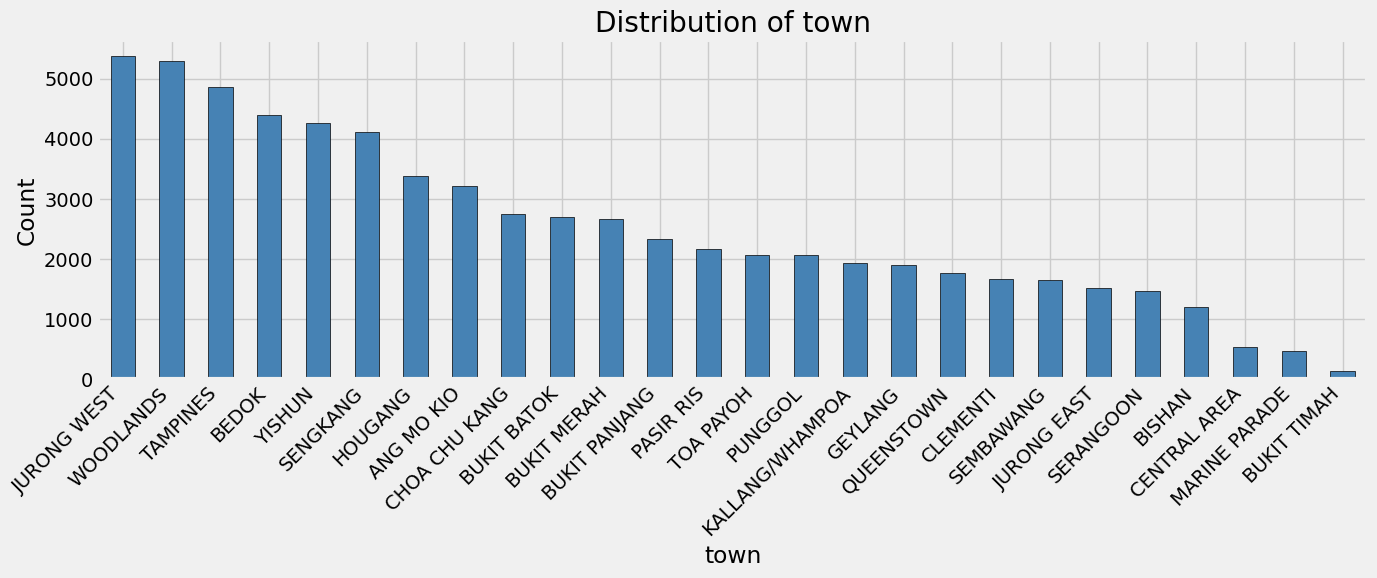

In [50]:
# Check target variable distribution
print(f"Target variable distribution ({TARGET_COLUMN}):")
print(df[TARGET_COLUMN].value_counts())

# Visualize target distribution
plt.figure(figsize=(14, 6))
df[TARGET_COLUMN].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title(f'Distribution of {TARGET_COLUMN}')
plt.xlabel(TARGET_COLUMN)
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

## Step 4: Exploratory Data Analysis (EDA) - Feature Distributions

For KNN classification, **correlation analysis is not as important** as it is for linear models. KNN is a distance-based algorithm that doesn't assume linear relationships between features and the target.

**What matters for KNN:**
- How well features **separate the classes** (visualized with boxplots)
- Feature **scale** (addressed with StandardScaler in Step 5)
- Feature **distribution** within each class

### 4a. Feature Distribution by Target Class (Boxplots)

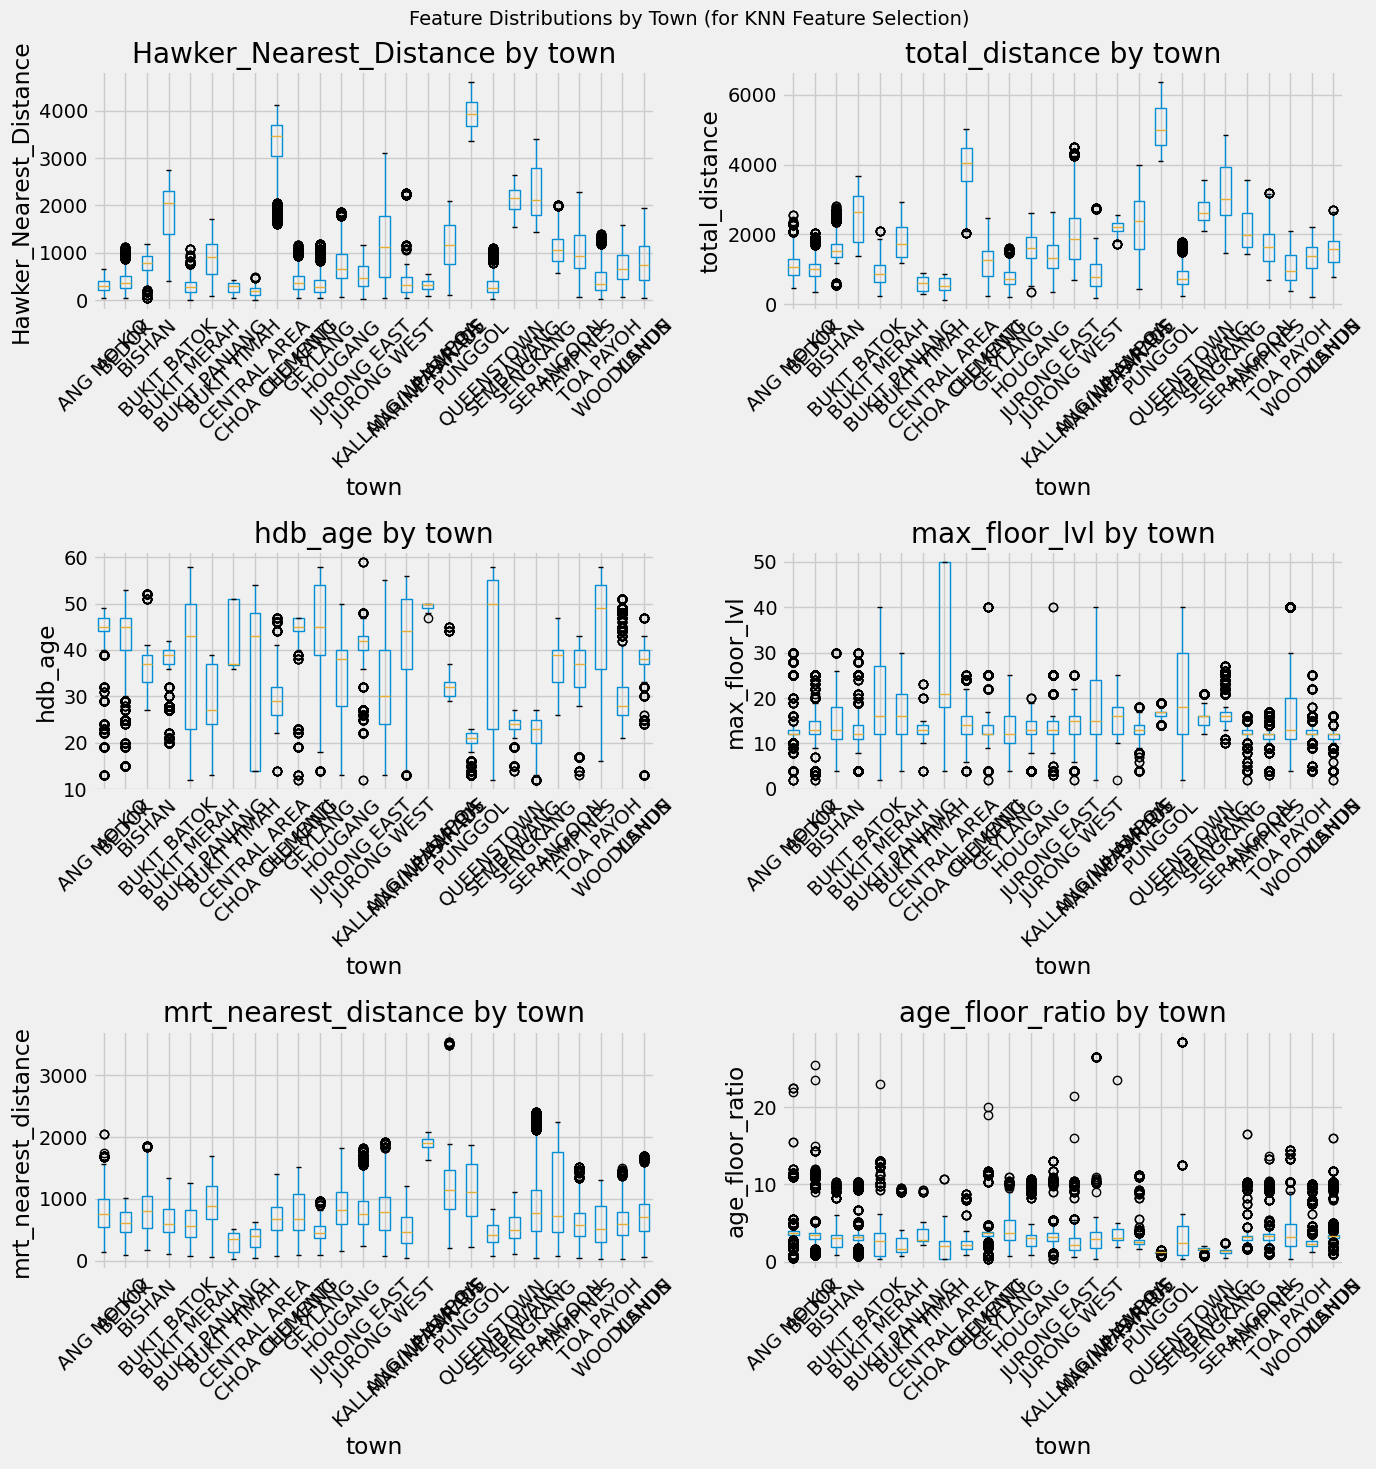

In [51]:
# ========== MODIFY THIS ==========
# Select features to visualize - ranked by Fisher Discriminant Ratio (class separation)
# Higher ratio = better separation between town classes
FEATURES_TO_PLOT = [
    'Hawker_Nearest_Distance', # Fisher: 4.43 - BEST separation
    'total_distance',          # Fisher: 2.65 - Engineered: MRT + Hawker distance
    'hdb_age',                 # Fisher: 0.45 - Good separation
    'max_floor_lvl',           # Fisher: 0.23 - Moderate separation
    'mrt_nearest_distance',    # Fisher: 0.20 - Moderate separation
    'age_floor_ratio',         # Fisher: 0.19 - Engineered: hdb_age / max_floor_lvl
]
# Note: floor_ratio REMOVED (Fisher: 0.0015 - almost no class separation)
# =================================

# Box plots for key features by target class
# This shows how well each feature separates the different classes
n_features = len(FEATURES_TO_PLOT)
n_cols = 2
n_rows = (n_features + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(FEATURES_TO_PLOT):
    if col in df.columns:
        df.boxplot(column=col, by=TARGET_COLUMN, ax=axes[i])
        axes[i].set_title(f'{col} by {TARGET_COLUMN}')
        axes[i].set_xlabel(TARGET_COLUMN)
        axes[i].set_ylabel(col)
        axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots if odd number of features
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Town (for KNN Feature Selection)', fontsize=14)
plt.tight_layout()
plt.show()

**Interpreting Boxplots for KNN:**
- **Good features:** Show clear separation between classes (minimal overlap in boxes)
- **Less useful features:** Classes overlap significantly
- Features with better class separation will contribute more to accurate KNN predictions

### 4b. Class Separation Summary

In [52]:
# Calculate mean values per class to understand feature separation
class_means = df.groupby(TARGET_COLUMN)[FEATURES_TO_PLOT].mean()
print("Mean feature values by town:")
display(class_means.round(2))

Mean feature values by town:


,Hawker_Nearest_Distance,total_distance,hdb_age,max_floor_lvl,mrt_nearest_distance,age_floor_ratio
town,,,,,,
ANG MO KIO,313.83,1097.25,43.39,13.41,783.42,3.70
BEDOK,405.64,1016.93,41.98,13.54,611.29,3.55
BISHAN,760.88,1606.10,36.66,14.62,845.22,3.03
BUKIT BATOK,1881.58,2531.55,36.63,13.28,649.97,3.44
BUKIT MERAH,302.48,922.53,38.03,19.08,620.05,2.86
BUKIT PANJANG,887.53,1819.08,29.35,17.15,931.55,2.12
BUKIT TIMAH,269.11,593.23,42.24,13.22,324.12,3.50
CENTRAL AREA,188.11,572.76,36.25,26.88,384.65,2.01
CHOA CHU KANG,3273.99,3971.42,29.83,14.65,697.43,2.21


In [53]:
# Calculate standard deviation to understand spread
class_std = df.groupby(TARGET_COLUMN)[FEATURES_TO_PLOT].std()
print("Standard deviation by town:")
display(class_std.round(2))

Standard deviation by town:


,Hawker_Nearest_Distance,total_distance,hdb_age,max_floor_lvl,mrt_nearest_distance,age_floor_ratio
town,,,,,,
ANG MO KIO,118.07,354.16,6.97,5.00,321.97,1.64
BEDOK,215.25,301.37,7.87,3.89,203.43,1.99
BISHAN,228.02,453.63,4.50,5.95,393.32,1.58
BUKIT BATOK,605.58,641.07,5.94,5.52,256.72,2.03
BUKIT MERAH,159.76,371.90,13.90,8.25,309.78,2.43
BUKIT PANJANG,407.72,504.50,6.42,6.27,382.66,1.44
BUKIT TIMAH,111.63,198.57,6.97,3.46,141.78,1.51
CENTRAL AREA,102.36,201.74,14.76,14.48,164.88,1.46
CHOA CHU KANG,620.26,647.74,5.64,3.57,289.90,0.89


### 4c. Optional: Correlation Matrix (for Multicollinearity Check Only)

> **Note:** Correlation is not used for feature-target relationship in KNN, but can help identify **multicollinearity** (highly correlated features that may be redundant).

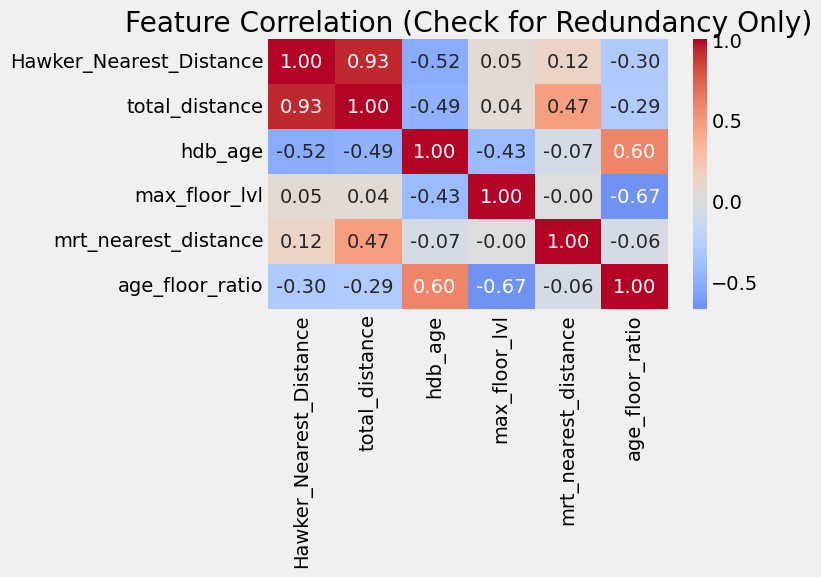


Highly correlated feature pairs (|r| > 0.8):
  Hawker_Nearest_Distance & total_distance = 0.93


In [54]:
# Optional: Check for redundant features (multicollinearity)
numeric_cols = df[FEATURES_TO_PLOT]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Feature Correlation (Check for Redundancy Only)')
plt.tight_layout()
plt.show()

# Flag highly correlated feature pairs (consider removing one)
CORRELATION_THRESHOLD = 0.8
print(f"\nHighly correlated feature pairs (|r| > {CORRELATION_THRESHOLD}):")
found_high_corr = False
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > CORRELATION_THRESHOLD:
            print(f"  {corr_matrix.columns[i]} & {corr_matrix.columns[j]} = {corr_matrix.iloc[i, j]:.2f}")
            found_high_corr = True
if not found_high_corr:
    print("  None found - features are not highly correlated with each other.")

---

## Step 5: Model Preprocessing

### 5a. Map Categorical Labels to Numeric Labels

In [55]:
# ========== MODIFY THIS ==========
TARGET_NUMERIC_COL = 'town_num'  # Name for the new numeric column
# =================================

# Map target to numeric values
df[TARGET_NUMERIC_COL] = df[TARGET_COLUMN].map(TARGET_MAPPING)

# Check for any unmapped values (NaN)
unmapped = df[df[TARGET_NUMERIC_COL].isna()][TARGET_COLUMN].unique()
if len(unmapped) > 0:
    print(f"WARNING: Unmapped values found: {unmapped}")
    print("Update TARGET_MAPPING to include these values.")
else:
    print("All target values successfully mapped!")

# Verify mapping
print("\nTarget mapping verification:")
print(df[[TARGET_COLUMN, TARGET_NUMERIC_COL]].drop_duplicates().sort_values(TARGET_NUMERIC_COL))

All target values successfully mapped!

Target mapping verification:
                 town  town_num
0          ANG MO KIO         0
98              BEDOK         1
208            BISHAN         2
248       BUKIT BATOK         3
333       BUKIT MERAH         4
415     BUKIT PANJANG         5
459       BUKIT TIMAH         6
464      CENTRAL AREA         7
473     CHOA CHU KANG         8
572          CLEMENTI         9
613           GEYLANG        10
678           HOUGANG        11
778       JURONG EAST        12
829       JURONG WEST        13
978   KALLANG/WHAMPOA        14
1030    MARINE PARADE        15
1043        PASIR RIS        16
1095          PUNGGOL        17
1175       QUEENSTOWN        18
1228        SEMBAWANG        19
1262         SENGKANG        20
1352        SERANGOON        21
1396         TAMPINES        22
1532        TOA PAYOH        23
1597        WOODLANDS        24
1774           YISHUN        25


### 5b. Define Feature Columns and Set X and y

In [56]:
# ========== MODIFY THIS ==========
# Features selected based on Fisher Discriminant Ratio (class separation metric)
# Higher ratio = better separation between town classes = more useful for KNN

# Core features (ranked by class separation, no missing values)
NUMERIC_FEATURES = [
    'Hawker_Nearest_Distance', # Fisher: 4.43 - BEST separation
    'max_floor_lvl',           # Fisher: 0.23 - Moderate separation
    'mrt_nearest_distance',    # Fisher: 0.20 - Moderate separation
    'hdb_age',                 # Fisher: 0.45 - Good separation
]
# Note: floor_area_sqm removed (Fisher: 0.16 - low separation)

# Engineered features (created in Step 3.5)
ENGINEERED_FEATURES = [
    'total_distance',          # Fisher: 2.65 - EXCELLENT separation (mrt + hawker)
    'age_floor_ratio',         # Fisher: 0.19 - Moderate separation (age / floor_lvl)
]
# Note: floor_ratio REMOVED (Fisher: 0.0015 - almost no class separation)

# All features combined
FEATURE_COLUMNS = NUMERIC_FEATURES + ENGINEERED_FEATURES
# =================================

# Verify all features exist in dataframe
missing_cols = [col for col in FEATURE_COLUMNS if col not in df.columns]
if missing_cols:
    print(f"WARNING: Missing columns: {missing_cols}")
    print("Make sure to run the Feature Engineering cell (Step 3.5) first!")
else:
    print(f"All {len(FEATURE_COLUMNS)} features found in dataset")
    print(f"  - Numeric features: {NUMERIC_FEATURES}")
    print(f"  - Engineered features: {ENGINEERED_FEATURES}")

# Create feature matrix (X) and target vector (y)
# Note: Null values were already dropped in Step 3
X = df[FEATURE_COLUMNS]
y = df[TARGET_NUMERIC_COL]

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

All 6 features found in dataset
  - Numeric features: ['Hawker_Nearest_Distance', 'max_floor_lvl', 'mrt_nearest_distance', 'hdb_age']
  - Engineered features: ['total_distance', 'age_floor_ratio']

X shape: (65953, 6)
y shape: (65953,)


In [57]:
# pd.concat([X, y], axis=1).to_csv('knn_hdb_preprocessed.csv', index=False)

### 5c. Split Data into Training and Testing Sets (Block-Level)

> **Why block-level, not row-level?**
> All model features (`mrt_nearest_distance`, `Hawker_Nearest_Distance`, `hdb_age`, `max_floor_lvl` and the two derived features) are **block-level properties** — every flat in the same HDB block has identical feature values. A standard row-level `train_test_split` would place ~98% of blocks in *both* training and test, inflating accuracy to ~99%+ because the model just memorises `{feature fingerprint → town}` rather than learning to generalise. The block-level split holds out **entire unseen blocks** for testing.


In [82]:

# ========== MODIFY THIS ==========
RANDOM_STATE = 42  # For reproducibility
TEST_SIZE = 0.25   # 25% of BLOCKS for testing
# =================================

# -----------------------------------------------------------------------
# BLOCK-LEVEL SPLIT (prevents data leakage)
# -----------------------------------------------------------------------
# All 6 model features are block-level properties: every flat in the same
# HDB block shares identical values for mrt_nearest_distance,
# Hawker_Nearest_Distance, hdb_age, max_floor_lvl (and the two derived
# features). A random row-level split leaks ~98% of blocks into both
# train and test, so the model just memorises {fingerprint → town} and
# reports inflated ~99%+ accuracy without generalising.
#
# Fix: hold out ENTIRE blocks for the test set (stratified by town so
# all 26 classes are represented in both splits).
# -----------------------------------------------------------------------

from collections import defaultdict

# Create a block identifier column (temporary, not used as a feature)
df['_block_id'] = df['block'].astype(str) + '|' + df['street_name']

# Group blocks by their town for stratified sampling
blocks_by_town = defaultdict(list)
for block_id, town_label in df.groupby('_block_id')['town'].first().items():
    blocks_by_town[town_label].append(block_id)

np.random.seed(RANDOM_STATE)
train_blocks, test_blocks = set(), set()
for town_label, blocks in blocks_by_town.items():
    shuffled = np.random.permutation(blocks)
    n_test = max(1, int(len(shuffled) * TEST_SIZE))
    test_blocks.update(shuffled[:n_test])
    train_blocks.update(shuffled[n_test:])

train_mask = df['_block_id'].isin(train_blocks)
test_mask  = df['_block_id'].isin(test_blocks)

X_train = X[train_mask].reset_index(drop=True)
X_test  = X[test_mask].reset_index(drop=True)
y_train = y[train_mask].reset_index(drop=True)
y_test  = y[test_mask].reset_index(drop=True)

print(f"Training set size: {X_train.shape[0]:,} rows  ({len(train_blocks):,} unique blocks)")
print(f"Testing set size:  {X_test.shape[0]:,} rows  ({len(test_blocks):,} unique blocks)")
print(f"\nBlock overlap between splits: 0  (no block appears in both)")
print(f"All 26 towns in train? {y_train.nunique() == len(TARGET_MAPPING)}")
print(f"All 26 towns in test?  {y_test.nunique() == len(TARGET_MAPPING)}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).round(3))


Training set size: 49,499 rows  (6,229 unique blocks)
Testing set size:  16,454 rows  (2,064 unique blocks)

Block overlap between splits: 0  (no block appears in both)
All 26 towns in train? True
All 26 towns in test?  True

Class distribution in training set:
town_num
13    0.080
24    0.080
22    0.073
1     0.066
25    0.065
20    0.063
11    0.052
0     0.049
3     0.043
8     0.042
4     0.040
5     0.035
16    0.033
23    0.033
17    0.030
14    0.029
10    0.028
18    0.027
19    0.025
9     0.025
12    0.023
21    0.023
2     0.019
7     0.008
15    0.007
6     0.002
Name: proportion, dtype: float64


### 5d. Feature Scaling with StandardScaler

**Why Scale?** KNN uses distance calculations, so features with larger scales can dominate the distance metric. StandardScaler normalizes features to have mean=0 and std=1.

In [83]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data ONLY, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier inspection (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS)

print("Scaled training data statistics:")
print(X_train_scaled_df.describe().round(2))

Scaled training data statistics:
       Hawker_Nearest_Distance  max_floor_lvl  mrt_nearest_distance   hdb_age  \
count                 49499.00       49499.00              49499.00  49499.00   
mean                     -0.00          -0.00                  0.00     -0.00   
std                       1.00           1.00                  1.00      1.00   
min                      -1.10          -2.27                 -1.77     -2.25   
25%                      -0.74          -0.44                 -0.72     -0.89   
50%                      -0.35          -0.26                 -0.17      0.18   
75%                       0.45           0.29                  0.50      0.66   
max                       3.51           6.51                  6.92      2.31   

       total_distance  age_floor_ratio  
count        49499.00         49499.00  
mean            -0.00            -0.00  
std              1.00             1.00  
min             -1.54            -1.41  
25%             -0.71           

---

## Step 6: Find Optimal K Value

Iterate through different K values to find the one that minimizes testing error.

In [84]:
# ========== MODIFY THIS ==========
K_MIN = 1
K_MAX = 50
K_STEP = 2  # Use odd numbers to avoid ties
# =================================

# Calculate training and testing error for different K values
k_range = list(range(K_MIN, K_MAX, K_STEP))
training_error = []
testing_error = []

for k in k_range:
    # Instantiate and fit the model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Calculate training error (error = 1 - accuracy)
    training_accuracy = knn.score(X_train_scaled, y_train)
    training_error.append(1 - training_accuracy)
    
    # Calculate testing error
    testing_accuracy = knn.score(X_test_scaled, y_test)
    testing_error.append(1 - testing_accuracy)

# Create results DataFrame
results_df = pd.DataFrame({
    'K': k_range,
    'training_error': training_error,
    'testing_error': testing_error,
    'training_accuracy': [1 - e for e in training_error],
    'testing_accuracy': [1 - e for e in testing_error]
}).set_index('K')

print("Top 10 K values (lowest testing error):")
print(results_df.sort_values('testing_error').head(10))

Top 10 K values (lowest testing error):
    training_error  testing_error  training_accuracy  testing_accuracy
K                                                                     
1         0.000000       0.262368           1.000000          0.737632
3         0.001879       0.263887           0.998121          0.736113
5         0.006202       0.265042           0.993798          0.734958
7         0.013758       0.268749           0.986242          0.731251
9         0.022162       0.272882           0.977838          0.727118
11        0.033597       0.280357           0.966403          0.719643
21        0.094790       0.286860           0.905210          0.713140
23        0.105618       0.288927           0.894382          0.711073
13        0.045193       0.289413           0.954807          0.710587
15        0.058648       0.290325           0.941352          0.709675


### Visualize Training vs Testing Error

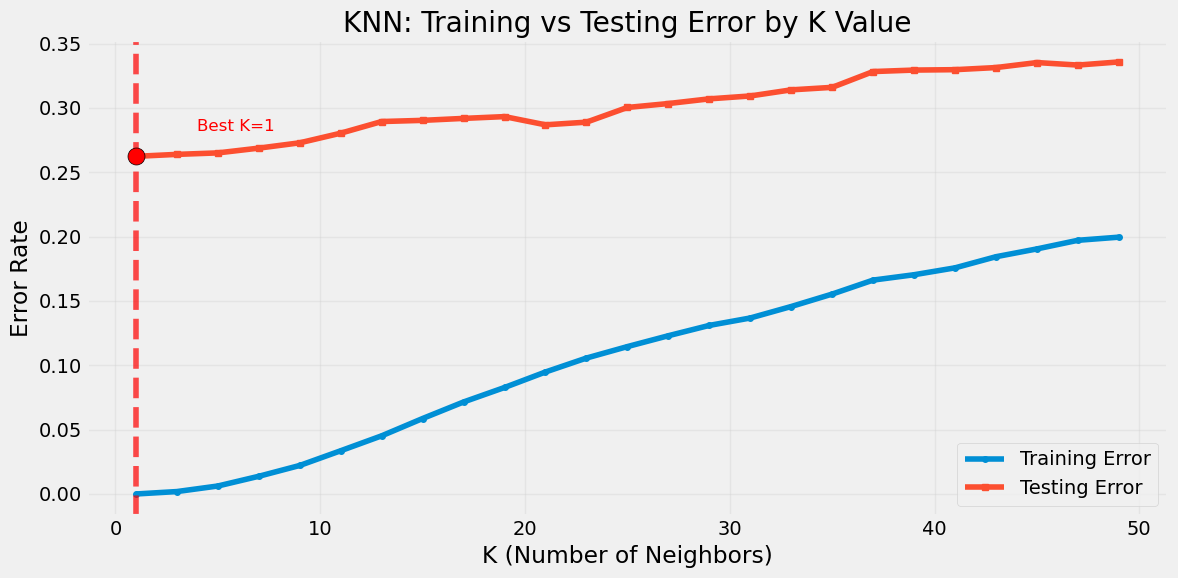


Optimal K value: 1
Testing error at K=1: 0.2624
Testing accuracy at K=1: 0.7376


In [85]:
# Plot error curves
plt.figure(figsize=(12, 6))
plt.plot(k_range, training_error, label='Training Error', marker='o', markersize=4)
plt.plot(k_range, testing_error, label='Testing Error', marker='s', markersize=4)
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Error Rate')
plt.title('KNN: Training vs Testing Error by K Value')
plt.legend()
plt.grid(True, alpha=0.3)

# Mark the optimal K
best_k = results_df['testing_error'].idxmin()
best_error = results_df.loc[best_k, 'testing_error']
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
plt.scatter([best_k], [best_error], color='red', s=150, zorder=5, edgecolor='black')
plt.annotate(f'Best K={best_k}', xy=(best_k, best_error), xytext=(best_k+3, best_error+0.02),
             fontsize=12, color='red')

plt.tight_layout()
plt.show()

print(f"\nOptimal K value: {best_k}")
print(f"Testing error at K={best_k}: {best_error:.4f}")
print(f"Testing accuracy at K={best_k}: {1 - best_error:.4f}")

---

## Step 7: Train Final Model and Evaluate

Train the model with the optimal K value and evaluate performance.

In [86]:
# Find best K from results
best_k = results_df['testing_error'].idxmin()

# Train final model
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

# Calculate scores
train_accuracy = knn_final.score(X_train_scaled, y_train)
test_accuracy = knn_final.score(X_test_scaled, y_test)
train_error = 1 - train_accuracy
test_error = 1 - test_accuracy

# Display results
print("=" * 60)
print("                  FINAL MODEL PERFORMANCE")
print("=" * 60)
print(f"Best K Value: {best_k}")
print()
print(f"  train_accuracy: {train_accuracy:.4f}")
print(f"  test_accuracy:  {test_accuracy:.4f}")
print()
print(f"  train_error:    {train_error:.4f}")
print(f"  test_error:     {test_error:.4f}")
print("=" * 60)

                  FINAL MODEL PERFORMANCE
Best K Value: 1

  train_accuracy: 1.0000
  test_accuracy:  0.7376

  train_error:    0.0000
  test_error:     0.2624


### Detailed Classification Report

In [87]:
# Make predictions
y_pred = knn_final.predict(X_test_scaled)

# Get the class labels that are actually present in the data
present_classes = sorted(y.unique())
present_labels = [k for k, v in sorted(TARGET_MAPPING.items(), key=lambda x: x[1]) if v in present_classes]

# Classification report
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=present_labels, zero_division=0))

Classification Report:
                 precision    recall  f1-score   support

     ANG MO KIO       0.66      0.69      0.67       793
          BEDOK       0.66      0.60      0.63      1133
         BISHAN       0.62      0.74      0.67       280
    BUKIT BATOK       0.87      0.80      0.83       589
    BUKIT MERAH       0.62      0.65      0.64       692
  BUKIT PANJANG       0.65      0.66      0.66       617
    BUKIT TIMAH       0.66      0.68      0.67        31
   CENTRAL AREA       0.82      0.61      0.70       136
  CHOA CHU KANG       0.92      0.93      0.93       693
       CLEMENTI       0.64      0.71      0.67       440
        GEYLANG       0.64      0.62      0.63       504
        HOUGANG       0.63      0.56      0.59       814
    JURONG EAST       0.57      0.58      0.57       385
    JURONG WEST       0.77      0.78      0.77      1390
KALLANG/WHAMPOA       0.56      0.52      0.54       496
  MARINE PARADE       1.00      1.00      1.00       130
      P

Confusion Matrix:
[[ 544   50    0    0   32    0    0   18    0   17   20   24    0   50
     9    0    0    0    3    0    0    0    0    0   18    8]
 [ 126  684   15    0   17    2    0    0    0   82   32    3    6   48
    39    0    0    0    0    0    0    0   23    0   40   16]
 [   0    7  206    0    0   18    0    0    0    0    0   18    0    0
     0    0   13    0    0    0    0    1    3    0    0   14]
 [   0    7    0  469    0    2    0    0    6    0    0   14   10   19
    15    0    0    0    0    0    0   10    2   10    0   25]
 [  12   56    0    0  452    0    0    0    0   15   17    8   15    4
    13    0    0    0   41    0    0    0   13   46    0    0]
 [   0    0    1    0    0  408    0    0    0    0    0   59   10    9
     0    0    3    0    0    0    0    0    9    9   14   95]
 [   0    0    0    0    0    0   21    0    0    0    0    0    0    0
    10    0    0    0    0    0    0    0    0    0    0    0]
 [   2    2    0    0    0    0    0 

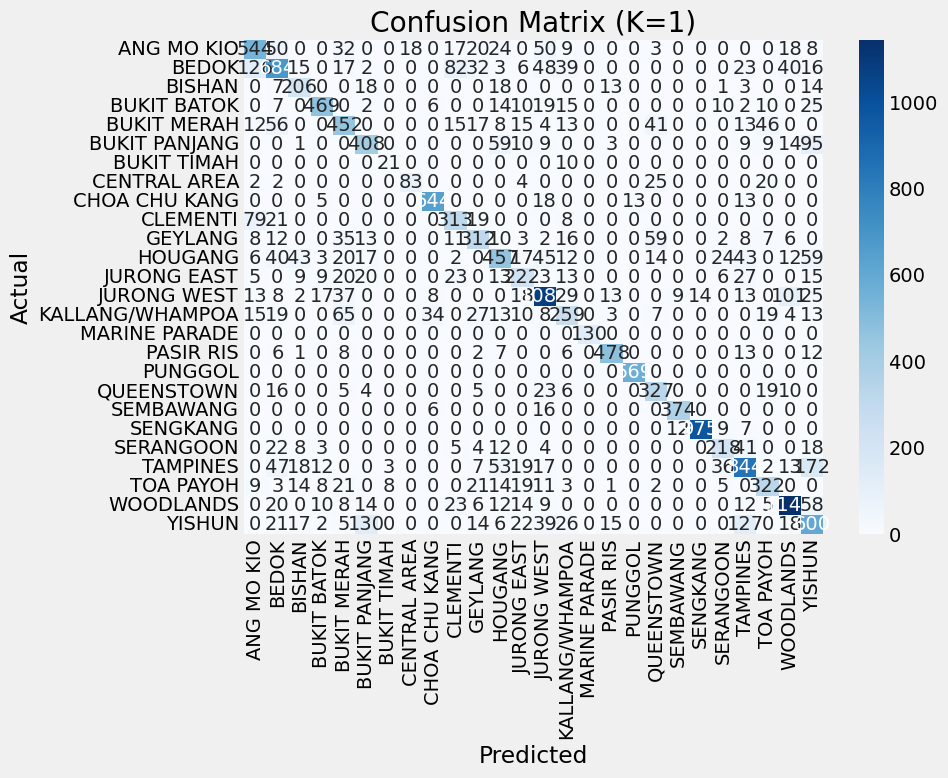

In [88]:
# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_labels,
            yticklabels=present_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (K={best_k})')
plt.tight_layout()
plt.show()

---

## Step 8: Define Model Evaluation Helper Functions

Create reusable functions to train each classifier and display its performance — mirroring the same pattern used for each model in Steps 9–12.


In [89]:

def evaluate_classification_model(model, X_train, X_test, y_train, y_test, model_name, class_names):
    """
    Train a classification model and return evaluation metrics.

    Parameters
    ----------
    model        : sklearn-compatible classifier
    X_train/Test : feature DataFrames (raw, unscaled — tree models do not need scaling)
    y_train/test : target Series
    model_name   : display label
    class_names  : ordered list of class labels matching the numeric encoding

    Returns
    -------
    dict with Model, accuracies, errors, fitted_model, predictions,
         classification_report, and confusion_matrix.
    """
    model.fit(X_train, y_train)
    y_test_pred  = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    # CatBoost returns float objects — cast to int so sklearn metrics work correctly
    if 'CatBoost' in type(model).__name__:
        y_test_pred  = np.array(y_test_pred).astype(int).ravel()
        y_train_pred = np.array(y_train_pred).astype(int).ravel()

    train_accuracy = model.score(X_train, y_train)
    test_accuracy  = model.score(X_test,  y_test)

    return {
        'Model':                 model_name,
        'Train Accuracy':        train_accuracy,
        'Test Accuracy':         test_accuracy,
        'Train Error':           1 - train_accuracy,
        'Test Error':            1 - test_accuracy,
        'fitted_model':          model,
        'y_test_pred':           y_test_pred,
        'classification_report': classification_report(
                                     y_test, y_test_pred,
                                     target_names=class_names,
                                     zero_division=0),
        'confusion_matrix':      confusion_matrix(y_test, y_test_pred),
    }


def display_classification_results(results):
    """Print a compact accuracy / error summary for one model."""
    print("=" * 90)
    print(f"  MODEL: {results['Model']}")
    print("=" * 90)
    print(f"  Train Accuracy : {results['Train Accuracy']:.4f}   |   Train Error : {results['Train Error']:.4f}")
    print(f"  Test  Accuracy : {results['Test Accuracy']:.4f}   |   Test  Error : {results['Test Error']:.4f}")
    print("=" * 90)
    print()


print("evaluate_classification_model() and display_classification_results() defined!")


evaluate_classification_model() and display_classification_results() defined!


In [90]:

# Prepare shared inputs used by every model evaluation cell (Steps 9–12).
# All models are evaluated on the SAME train/test split for a fair comparison.
# X_train, X_test, y_train, y_test were created in Step 5c.

# Class names — town labels in the same sorted order as the numeric encoding
class_names = [label for label, _ in sorted(TARGET_MAPPING.items(), key=lambda x: x[1])]

print(f"Shared train / test split : {len(X_train)} train | {len(X_test)} test")
print(f"Class names ({len(class_names)} towns)  : {class_names}")
print()
print("Note: KNN (Steps 6–7) uses X_train_scaled / X_test_scaled (scaling is")
print("      handled by its Pipeline).  Tree models below use raw X_train / X_test.")


Shared train / test split : 49499 train | 16454 test
Class names (26 towns)  : ['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG', 'BUKIT TIMAH', 'CENTRAL AREA', 'CHOA CHU KANG', 'CLEMENTI', 'GEYLANG', 'HOUGANG', 'JURONG EAST', 'JURONG WEST', 'KALLANG/WHAMPOA', 'MARINE PARADE', 'PASIR RIS', 'PUNGGOL', 'QUEENSTOWN', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'TAMPINES', 'TOA PAYOH', 'WOODLANDS', 'YISHUN']

Note: KNN (Steps 6–7) uses X_train_scaled / X_test_scaled (scaling is
      handled by its Pipeline).  Tree models below use raw X_train / X_test.


---

## Step 9: Random Forest Model

An ensemble of decision trees that votes on the most likely class.  
No feature scaling required — Random Forest is scale-invariant.


In [91]:

# ========== RANDOM FOREST ==========
# Tree-based models are scale-invariant — use raw X_train / X_test from Step 5c.
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight='balanced_subsample',
    n_jobs=-1
)

rf_results = evaluate_classification_model(
    rf_model, X_train, X_test, y_train, y_test,
    'Random Forest', class_names
)

display_classification_results(rf_results)


  MODEL: Random Forest
  Train Accuracy : 1.0000   |   Train Error : 0.0000
  Test  Accuracy : 0.7684   |   Test  Error : 0.2316



Classification Report — Random Forest:
                 precision    recall  f1-score   support

     ANG MO KIO       0.65      0.75      0.70       793
          BEDOK       0.69      0.63      0.66      1133
         BISHAN       0.75      0.74      0.75       280
    BUKIT BATOK       0.86      0.88      0.87       589
    BUKIT MERAH       0.69      0.66      0.68       692
  BUKIT PANJANG       0.75      0.74      0.74       617
    BUKIT TIMAH       0.91      1.00      0.95        31
   CENTRAL AREA       0.65      0.64      0.64       136
  CHOA CHU KANG       1.00      0.94      0.97       693
       CLEMENTI       0.62      0.53      0.57       440
        GEYLANG       0.55      0.51      0.53       504
        HOUGANG       0.70      0.67      0.69       814
    JURONG EAST       0.65      0.65      0.65       385
    JURONG WEST       0.74      0.78      0.76      1390
KALLANG/WHAMPOA       0.61      0.53      0.57       496
  MARINE PARADE       1.00      1.00      1.00  

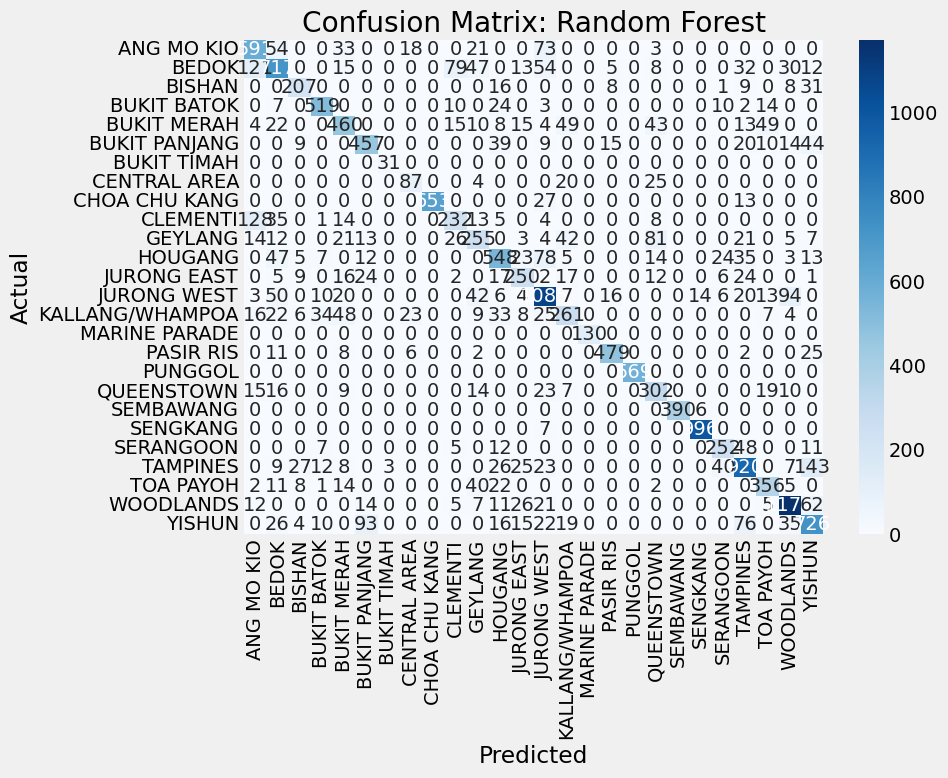

In [92]:

# Detailed Classification Report — Random Forest
print("Classification Report — Random Forest:")
print("=" * 90)
print(rf_results['classification_report'])
print("=" * 90)

# Confusion matrix heatmap
cm_rf = rf_results['confusion_matrix']
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Random Forest')
plt.tight_layout()
plt.show()


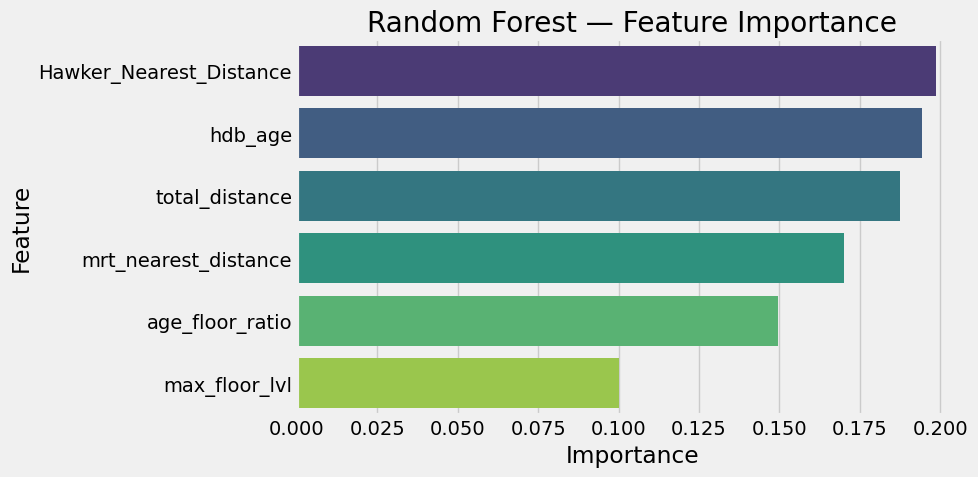

Feature Importance:
                Feature  Importance
Hawker_Nearest_Distance    0.198679
                hdb_age    0.194209
         total_distance    0.187332
   mrt_nearest_distance    0.170115
        age_floor_ratio    0.149604
          max_floor_lvl    0.100062


In [93]:

# Feature importance — Random Forest
# Higher importance means the model relies more on that feature when splitting trees.
rf_importance = pd.DataFrame({
    'Feature':    FEATURE_COLUMNS,
    'Importance': rf_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=rf_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(rf_importance.to_string(index=False))


---

## Step 10: LightGBM Model

Gradient boosting with fast leaf-wise tree growth.  
No feature scaling required — LightGBM is scale-invariant.


In [94]:

# ========== LIGHTGBM ==========
if LGBMClassifier is not None:
    lgbm_model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=RANDOM_STATE
    )
    lgbm_results = evaluate_classification_model(
        lgbm_model, X_train, X_test, y_train, y_test,
        'LightGBM', class_names
    )
    display_classification_results(lgbm_results)
else:
    print("LightGBM is not installed. Run:  pip install lightgbm")
    lgbm_results = None


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001058 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1097
[LightGBM] [Info] Number of data points in the train set: 49499, number of used features: 6
[LightGBM] [Info] Start training from score -3.015709
[LightGBM] [Info] Start training from score -2.716551
[LightGBM] [Info] Start training from score -3.984248
[LightGBM] [Info] Start training from score -3.156687
[LightGBM] [Info] Start training from score -3.223411
[LightGBM] [Info] Start training from score -3.360210
[LightGBM] [Info] Start training from score -6.118360
[LightGBM] [Info] Start training from score -4.828294
[LightGBM] [Info] Start training from score -3.177307
[LightGBM] [Info] Start training from score -3.690881
[LightGBM] [Info] Start training from score -3.561915
[LightGBM] [Info] Start training from score -2.960384
[LightGBM] [Info] Start training from score -3.770047
[LightGBM]

Classification Report — LightGBM:
                 precision    recall  f1-score   support

     ANG MO KIO       0.59      0.66      0.62       793
          BEDOK       0.61      0.62      0.62      1133
         BISHAN       0.67      0.72      0.70       280
    BUKIT BATOK       0.85      0.84      0.84       589
    BUKIT MERAH       0.66      0.63      0.65       692
  BUKIT PANJANG       0.72      0.68      0.70       617
    BUKIT TIMAH       1.00      0.42      0.59        31
   CENTRAL AREA       0.57      0.46      0.51       136
  CHOA CHU KANG       0.95      0.95      0.95       693
       CLEMENTI       0.65      0.52      0.58       440
        GEYLANG       0.63      0.50      0.56       504
        HOUGANG       0.58      0.61      0.59       814
    JURONG EAST       0.69      0.68      0.68       385
    JURONG WEST       0.72      0.77      0.74      1390
KALLANG/WHAMPOA       0.55      0.46      0.50       496
  MARINE PARADE       1.00      1.00      1.00       

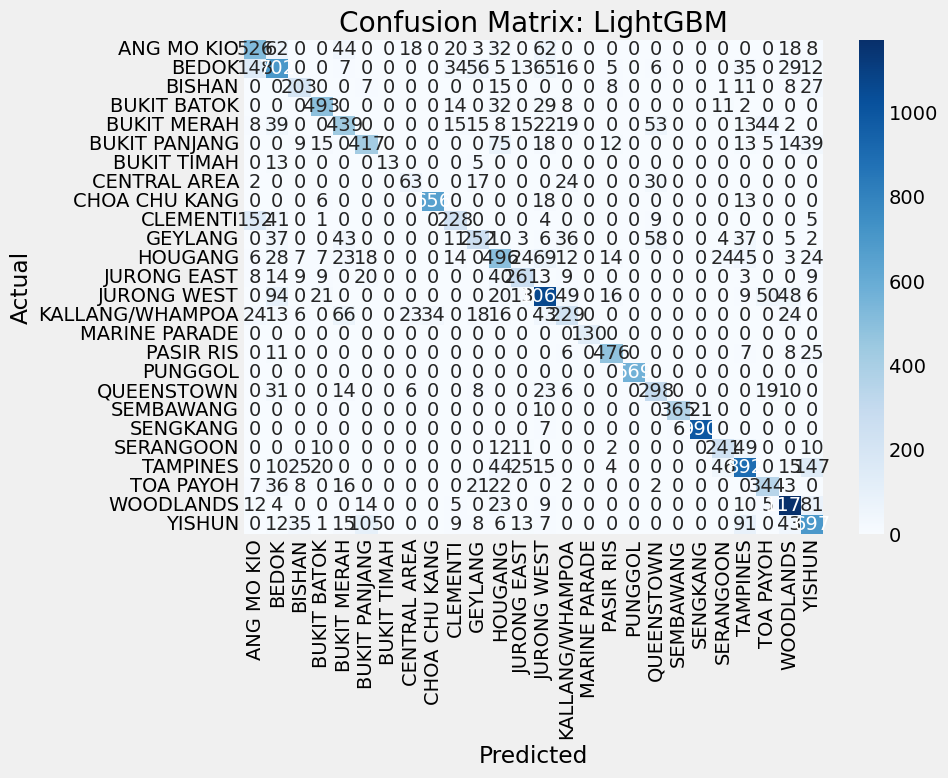

In [95]:

# Detailed Classification Report — LightGBM
if globals().get('lgbm_results') is not None:
    print("Classification Report — LightGBM:")
    print("=" * 90)
    print(lgbm_results['classification_report'])
    print("=" * 90)

    cm_lgbm = lgbm_results['confusion_matrix']
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: LightGBM')
    plt.tight_layout()
    plt.show()


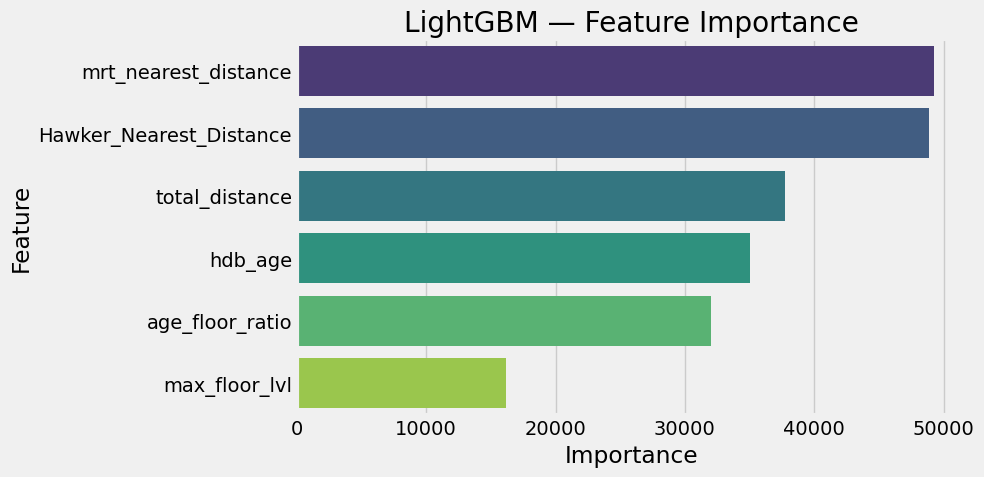

Feature Importance:
                Feature  Importance
   mrt_nearest_distance       49229
Hawker_Nearest_Distance       48906
         total_distance       37754
                hdb_age       35030
        age_floor_ratio       32044
          max_floor_lvl       16146


In [96]:

# Feature importance — LightGBM
if globals().get('lgbm_results') is not None:
    lgbm_importance = pd.DataFrame({
        'Feature':    FEATURE_COLUMNS,
        'Importance': lgbm_results['fitted_model'].feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=lgbm_importance, x='Importance', y='Feature', palette='viridis')
    plt.title('LightGBM — Feature Importance')
    plt.tight_layout()
    plt.show()

    print("Feature Importance:")
    print(lgbm_importance.to_string(index=False))


---

## Step 11: XGBoost Model

Gradient boosting with level-wise tree growth and built-in regularisation (L1/L2).  
No feature scaling required — XGBoost is scale-invariant.


In [97]:

# ========== XGBOOST ==========
if XGBClassifier is not None:
    xgb_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='multi:softmax',
        num_class=len(TARGET_MAPPING),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='mlogloss'
    )
    xgb_results = evaluate_classification_model(
        xgb_model, X_train, X_test, y_train, y_test,
        'XGBoost', class_names
    )
    display_classification_results(xgb_results)
else:
    print("XGBoost is not installed. Run:  pip install xgboost")
    xgb_results = None


  MODEL: XGBoost
  Train Accuracy : 0.9902   |   Train Error : 0.0098
  Test  Accuracy : 0.7463   |   Test  Error : 0.2537



Classification Report — XGBoost:
                 precision    recall  f1-score   support

     ANG MO KIO       0.56      0.55      0.56       793
          BEDOK       0.59      0.72      0.65      1133
         BISHAN       0.73      0.73      0.73       280
    BUKIT BATOK       0.88      0.89      0.89       589
    BUKIT MERAH       0.65      0.60      0.62       692
  BUKIT PANJANG       0.71      0.69      0.70       617
    BUKIT TIMAH       1.00      1.00      1.00        31
   CENTRAL AREA       0.66      0.67      0.66       136
  CHOA CHU KANG       0.95      0.96      0.95       693
       CLEMENTI       0.72      0.61      0.66       440
        GEYLANG       0.69      0.47      0.56       504
        HOUGANG       0.60      0.66      0.63       814
    JURONG EAST       0.54      0.53      0.53       385
    JURONG WEST       0.77      0.78      0.77      1390
KALLANG/WHAMPOA       0.57      0.40      0.47       496
  MARINE PARADE       1.00      1.00      1.00       1

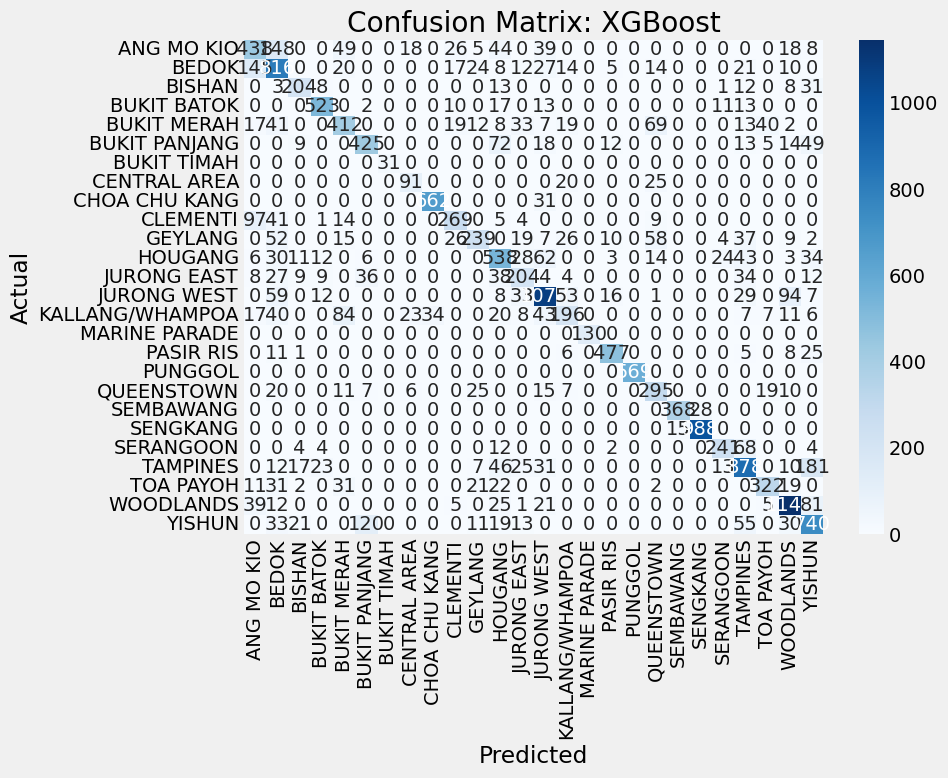

In [98]:

# Detailed Classification Report — XGBoost
if globals().get('xgb_results') is not None:
    print("Classification Report — XGBoost:")
    print("=" * 90)
    print(xgb_results['classification_report'])
    print("=" * 90)

    cm_xgb = xgb_results['confusion_matrix']
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: XGBoost')
    plt.tight_layout()
    plt.show()


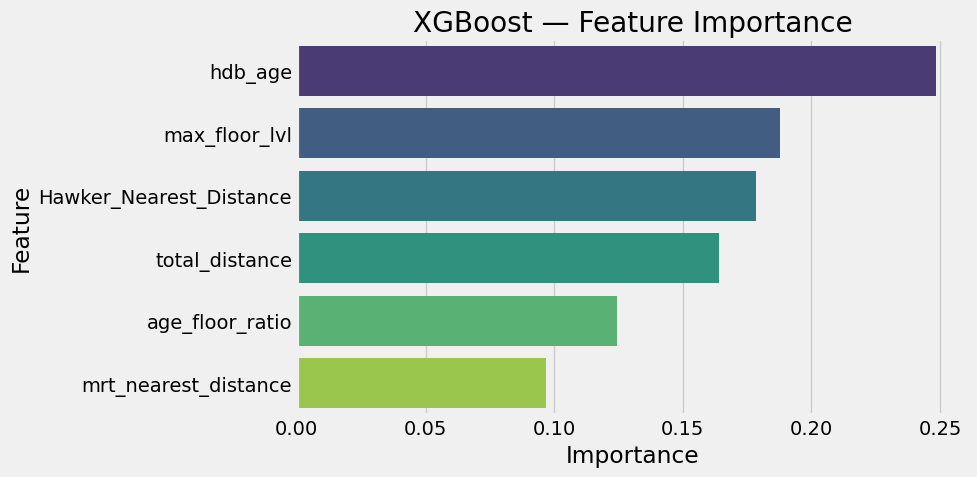

Feature Importance:
                Feature  Importance
                hdb_age    0.248421
          max_floor_lvl    0.187897
Hawker_Nearest_Distance    0.178261
         total_distance    0.164038
        age_floor_ratio    0.124488
   mrt_nearest_distance    0.096894


In [99]:

# Feature importance — XGBoost
if globals().get('xgb_results') is not None:
    xgb_importance = pd.DataFrame({
        'Feature':    FEATURE_COLUMNS,
        'Importance': xgb_results['fitted_model'].feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=xgb_importance, x='Importance', y='Feature', palette='viridis')
    plt.title('XGBoost — Feature Importance')
    plt.tight_layout()
    plt.show()

    print("Feature Importance:")
    print(xgb_importance.to_string(index=False))


---

## Step 12: CatBoost Model

Gradient boosting with built-in handling for class imbalance.  
No feature scaling required — CatBoost is scale-invariant.


In [100]:

# ========== CATBOOST ==========
if CatBoostClassifier is not None:
    catboost_model = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function='MultiClass',
        eval_metric='Accuracy',
        random_seed=RANDOM_STATE,
        verbose=0
    )
    catboost_results = evaluate_classification_model(
        catboost_model, X_train, X_test, y_train, y_test,
        'CatBoost', class_names
    )
    display_classification_results(catboost_results)
else:
    print("CatBoost is not installed. Run:  pip install catboost")
    catboost_results = None


  MODEL: CatBoost
  Train Accuracy : 0.8135   |   Train Error : 0.1865
  Test  Accuracy : 0.6922   |   Test  Error : 0.3078



Classification Report — CatBoost:
                 precision    recall  f1-score   support

     ANG MO KIO       0.54      0.69      0.60       793
          BEDOK       0.61      0.62      0.62      1133
         BISHAN       0.77      0.51      0.61       280
    BUKIT BATOK       0.88      0.76      0.82       589
    BUKIT MERAH       0.57      0.47      0.51       692
  BUKIT PANJANG       0.56      0.70      0.62       617
    BUKIT TIMAH       1.00      0.32      0.49        31
   CENTRAL AREA       0.74      0.75      0.74       136
  CHOA CHU KANG       0.98      0.90      0.94       693
       CLEMENTI       0.55      0.29      0.38       440
        GEYLANG       0.59      0.45      0.51       504
        HOUGANG       0.57      0.58      0.58       814
    JURONG EAST       0.42      0.38      0.40       385
    JURONG WEST       0.65      0.68      0.66      1390
KALLANG/WHAMPOA       0.65      0.39      0.49       496
  MARINE PARADE       1.00      1.00      1.00       

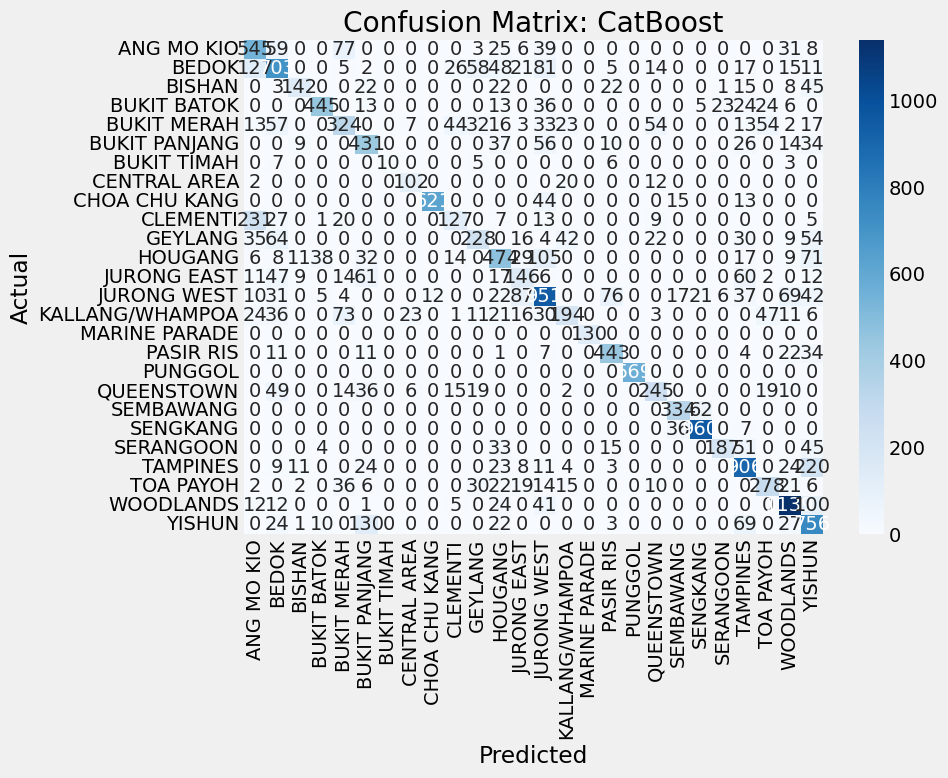

In [101]:

# Detailed Classification Report — CatBoost
if globals().get('catboost_results') is not None:
    print("Classification Report — CatBoost:")
    print("=" * 90)
    print(catboost_results['classification_report'])
    print("=" * 90)

    cm_catboost = catboost_results['confusion_matrix']
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_catboost, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: CatBoost')
    plt.tight_layout()
    plt.show()


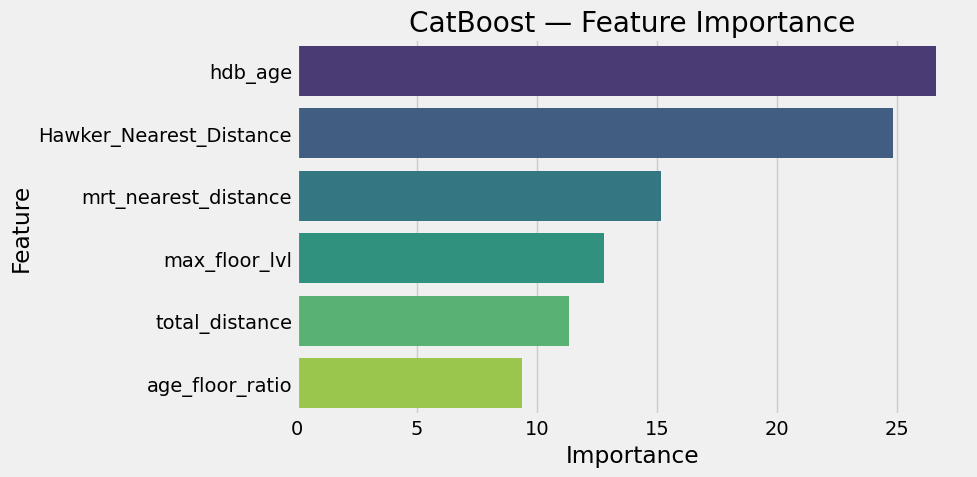

Feature Importance:
                Feature  Importance
                hdb_age   26.607057
Hawker_Nearest_Distance   24.803126
   mrt_nearest_distance   15.136556
          max_floor_lvl   12.772075
         total_distance   11.318430
        age_floor_ratio    9.362756


In [102]:

# Feature importance — CatBoost
if globals().get('catboost_results') is not None:
    catboost_importance = pd.DataFrame({
        'Feature':    FEATURE_COLUMNS,
        'Importance': catboost_results['fitted_model'].feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=catboost_importance, x='Importance', y='Feature', palette='viridis')
    plt.title('CatBoost — Feature Importance')
    plt.tight_layout()
    plt.show()

    print("Feature Importance:")
    print(catboost_importance.to_string(index=False))


---

## Step 13: Model Comparison Summary

Rank all trained models side-by-side on the same train/test split.


                    MODEL COMPARISON SUMMARY (5 Models)
        Model  Train Accuracy  Test Accuracy  Train Error  Test Error
Random Forest          1.0000         0.7684       0.0000      0.2316
      XGBoost          0.9902         0.7463       0.0098      0.2537
     LightGBM          0.9996         0.7424       0.0004      0.2576
    KNN (k=1)          1.0000         0.7376       0.0000      0.2624
     CatBoost          0.8135         0.6922       0.1865      0.3078

  Best Predicting Model: Random Forest


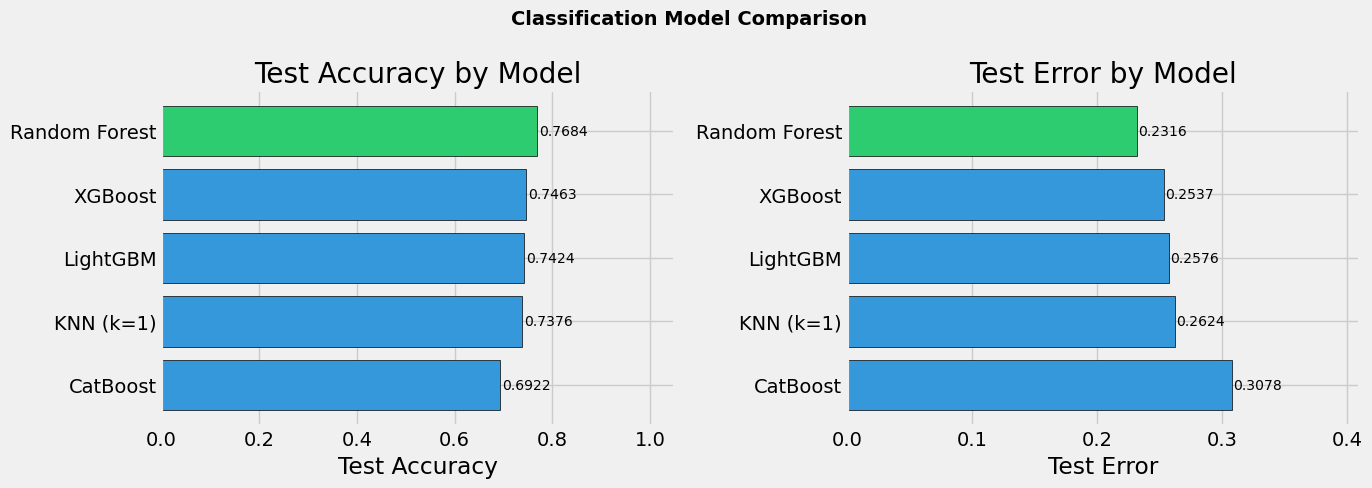

In [103]:

# Collect all trained model results for comparison.
# KNN metrics come from the variables produced in Steps 6-7.
knn_train_acc = knn_final.score(X_train_scaled, y_train)
knn_test_acc  = knn_final.score(X_test_scaled,  y_test)

all_comparison_results = [
    {
        'Model':          f'KNN (k={best_k})',
        'Train Accuracy': knn_train_acc,
        'Test Accuracy':  knn_test_acc,
        'Train Error':    1 - knn_train_acc,
        'Test Error':     1 - knn_test_acc,
    },
    rf_results,
]

for res in [
    globals().get('lgbm_results'),
    globals().get('xgb_results'),
    globals().get('catboost_results'),
]:
    if res is not None:
        all_comparison_results.append(res)

comparison_df = pd.DataFrame([
    {
        'Model':          r['Model'],
        'Train Accuracy': round(r['Train Accuracy'], 4),
        'Test Accuracy':  round(r['Test Accuracy'],  4),
        'Train Error':    round(r['Train Error'],     4),
        'Test Error':     round(r['Test Error'],      4),
    }
    for r in all_comparison_results
]).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("=" * 90)
print(f"                    MODEL COMPARISON SUMMARY ({len(comparison_df)} Models)")
print("=" * 90)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 90)
print(f"  Best Predicting Model: {comparison_df.loc[0, 'Model']}")
print("=" * 90)

# Bar chart
colors = ['#2ecc71' if m == comparison_df.loc[0, 'Model'] else '#3498db'
          for m in comparison_df['Model']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(comparison_df['Model'][::-1], comparison_df['Test Accuracy'][::-1],
             color=colors[::-1], edgecolor='black')
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Test Accuracy by Model')
axes[0].set_xlim(0, 1.05)
for i, acc in enumerate(comparison_df['Test Accuracy'][::-1]):
    axes[0].text(acc + 0.005, i, f'{acc:.4f}', va='center', fontsize=10)

axes[1].barh(comparison_df['Model'][::-1], comparison_df['Test Error'][::-1],
             color=colors[::-1], edgecolor='black')
axes[1].set_xlabel('Test Error')
axes[1].set_title('Test Error by Model')
axes[1].set_xlim(0, comparison_df['Test Error'].max() * 1.3 + 0.01)
for i, err in enumerate(comparison_df['Test Error'][::-1]):
    axes[1].text(err + 0.001, i, f'{err:.4f}', va='center', fontsize=10)

plt.suptitle('Classification Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

## Step 14: Confusion Matrix Gallery

Visualise class-level prediction behaviour for every model on the same test set.  
Each cell shows how many samples of each actual town were predicted as each other town.


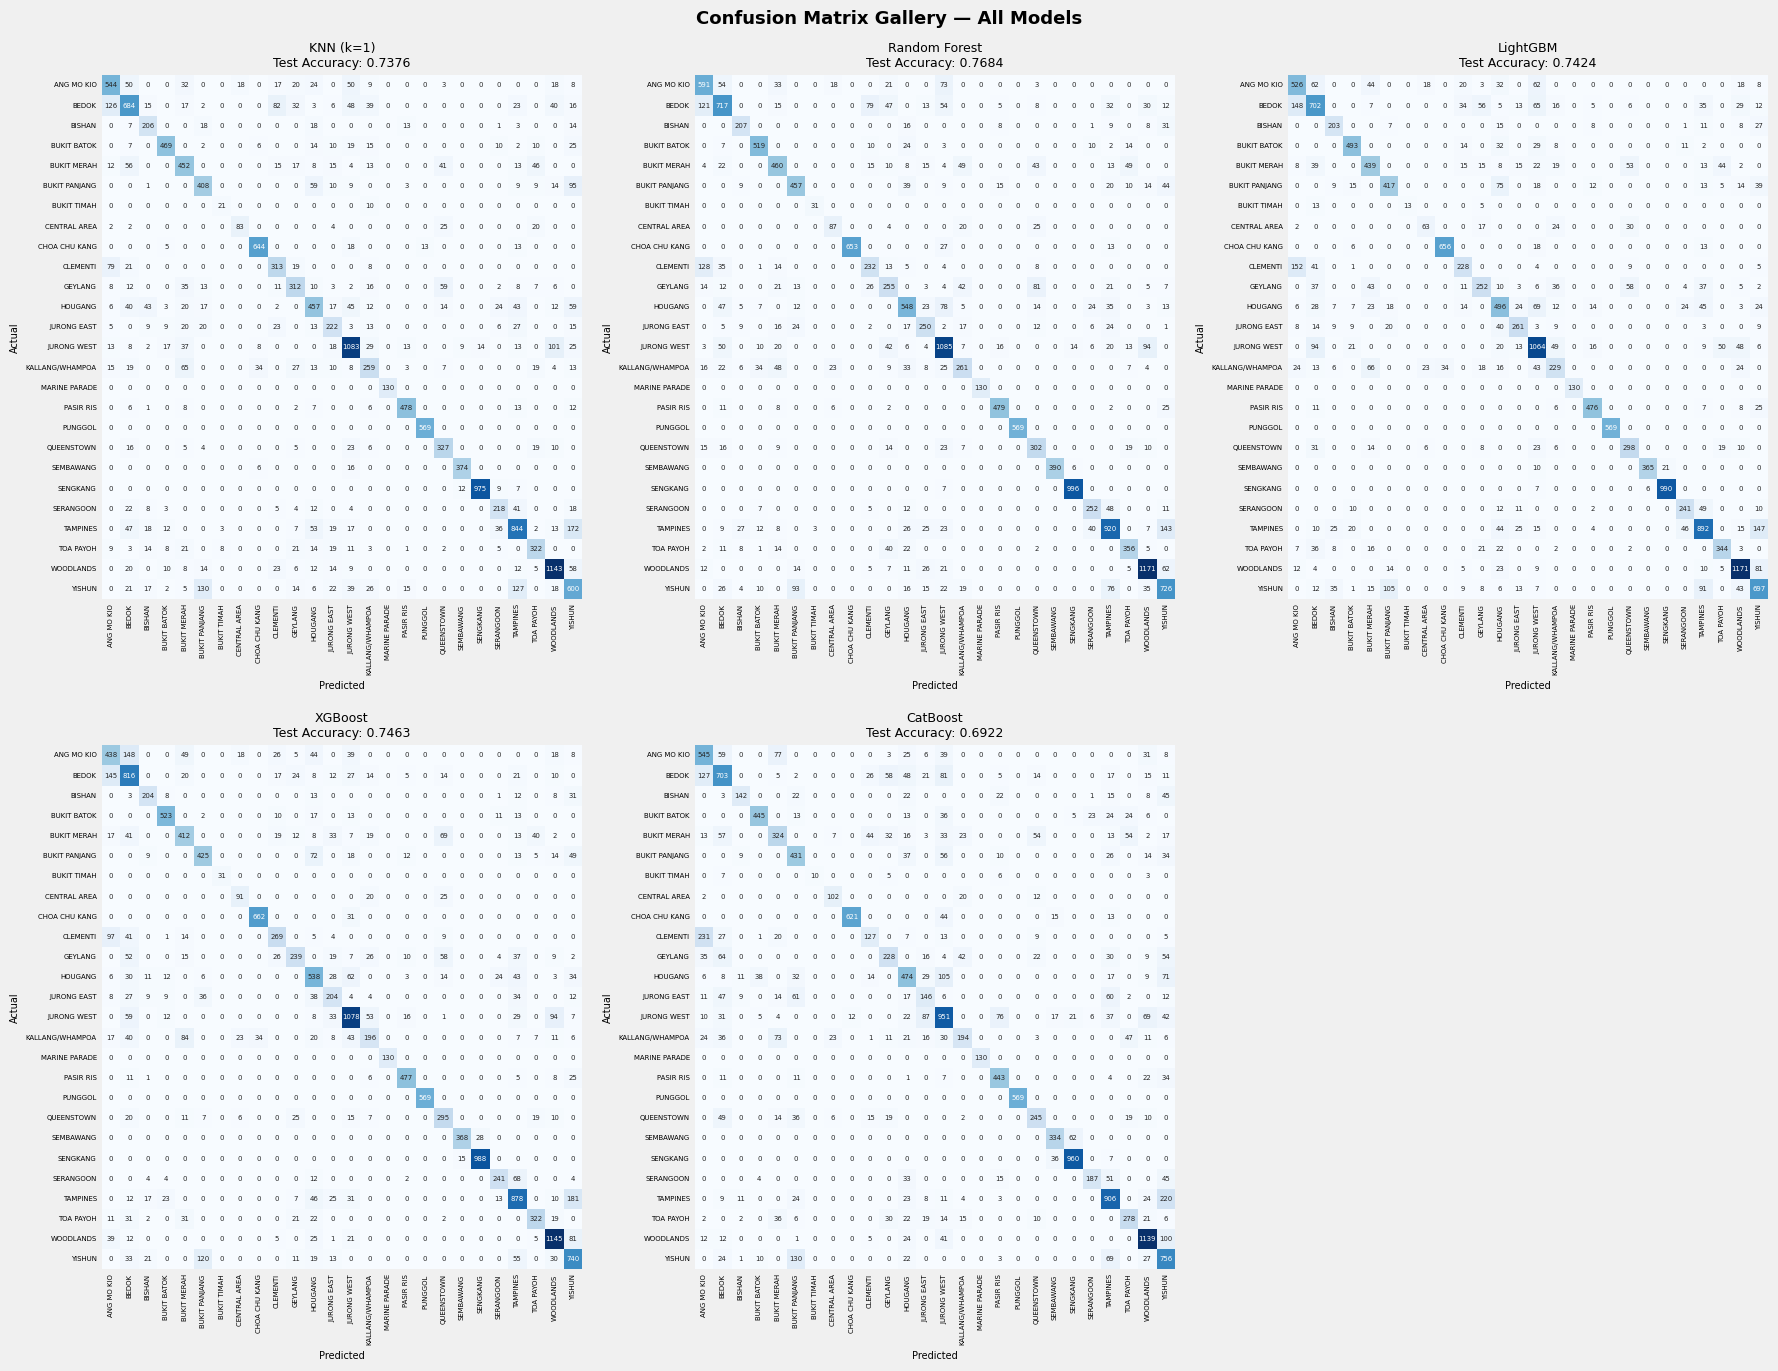

In [104]:

# Side-by-side confusion matrix gallery for all available models.
# Patch in KNN from the variables produced in Steps 6-7.
gallery_results = [
    {
        'Model':            f'KNN (k={best_k})',
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    },
    rf_results,
]

for res in [
    globals().get('lgbm_results'),
    globals().get('xgb_results'),
    globals().get('catboost_results'),
]:
    if res is not None:
        gallery_results.append(res)

n_models = len(gallery_results)
n_cols   = 3
n_rows   = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 7 * n_rows))
axes_flat = np.array(axes).flatten()

for idx, res in enumerate(gallery_results):
    ax   = axes_flat[idx]
    cm_i = res['confusion_matrix']
    sns.heatmap(cm_i, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar=False, annot_kws={'size': 5})
    acc_i = cm_i.diagonal().sum() / cm_i.sum()
    ax.set_title(f"{res['Model']}\nTest Accuracy: {acc_i:.4f}", fontsize=9)
    ax.set_xlabel('Predicted', fontsize=7)
    ax.set_ylabel('Actual',    fontsize=7)
    ax.tick_params(axis='both', labelsize=5)

for j in range(len(gallery_results), len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Confusion Matrix Gallery — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---

## Summary

| Step | Model | Type | Notes |
|------|-------|------|-------|
| Step 6–7 | KNN | Distance-based | Tuned via K search; requires feature scaling via Pipeline |
| Step 9   | Random Forest | Ensemble | 300 trees; balanced class weights; scale-invariant |
| Step 10  | LightGBM | Gradient Boosting | Fast leaf-wise growth; scale-invariant |
| Step 11  | XGBoost | Gradient Boosting | Level-wise with regularisation; scale-invariant |
| Step 12  | CatBoost | Gradient Boosting | Handles class imbalance; scale-invariant |
| Step 13  | Comparison | — | All models ranked on the same train/test split |
| Step 14  | Gallery | — | Confusion matrix per model for visual error analysis |

**How to reuse this notebook on a new dataset:**
1. Update `TARGET_COLUMN` and `DATA_PATH` in Steps 1–2
2. Adjust `FEATURE_COLUMNS` in Step 5b (and feature engineering in Step 3.5)
3. Re-run all cells — Steps 6–14 train and compare all models automatically
